# 🧬 Disease Symptom Classifier
### 246,945 samples | 377 binary symptoms | 773 disease classes
---
**Pipeline:** EDA → Preprocessing → Training → Evaluation → Inference

**Dataset:** `Disease and symptoms dataset.csv`

## 📦 Cell 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    classification_report,
    confusion_matrix
)

# ── Plot Style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d2e',
    'text.color'       : '#e0e0e0',
    'axes.labelcolor'  : '#e0e0e0',
    'xtick.color'      : '#aaaaaa',
    'ytick.color'      : '#aaaaaa',
    'axes.edgecolor'   : '#333355',
    'grid.color'       : '#2a2a3e',
    'axes.grid'        : True,
    'font.size'        : 10,
})
ACCENT  = '#7c6af7'
ACCENT2 = '#4fc3f7'
ACCENT3 = '#f06292'
ACCENT4 = '#81c784'

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## 📂 Cell 2 — Load Dataset

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('Disease and symptoms dataset.csv')

print(f'📊 Dataset Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'🦠 Unique Diseases : {df["diseases"].nunique()}')
print(f'🔬 Symptom Features: {df.shape[1] - 1}')
print(f'❌ Missing Values  : {df.isnull().sum().sum()}')
print()
print('--- First 5 rows ---')
df.head()

📊 Dataset Shape  : 246,945 rows × 378 columns
🦠 Unique Diseases : 773
🔬 Symptom Features: 377
❌ Missing Values  : 0

--- First 5 rows ---


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## 🔍 Cell 3 — EDA: Class Distribution

Max samples per class : 1,219  →  cystitis
Min samples per class : 1    →  gas gangrene
Mean samples per class: 319.5
Median                : 168
Imbalance ratio       : 1219×



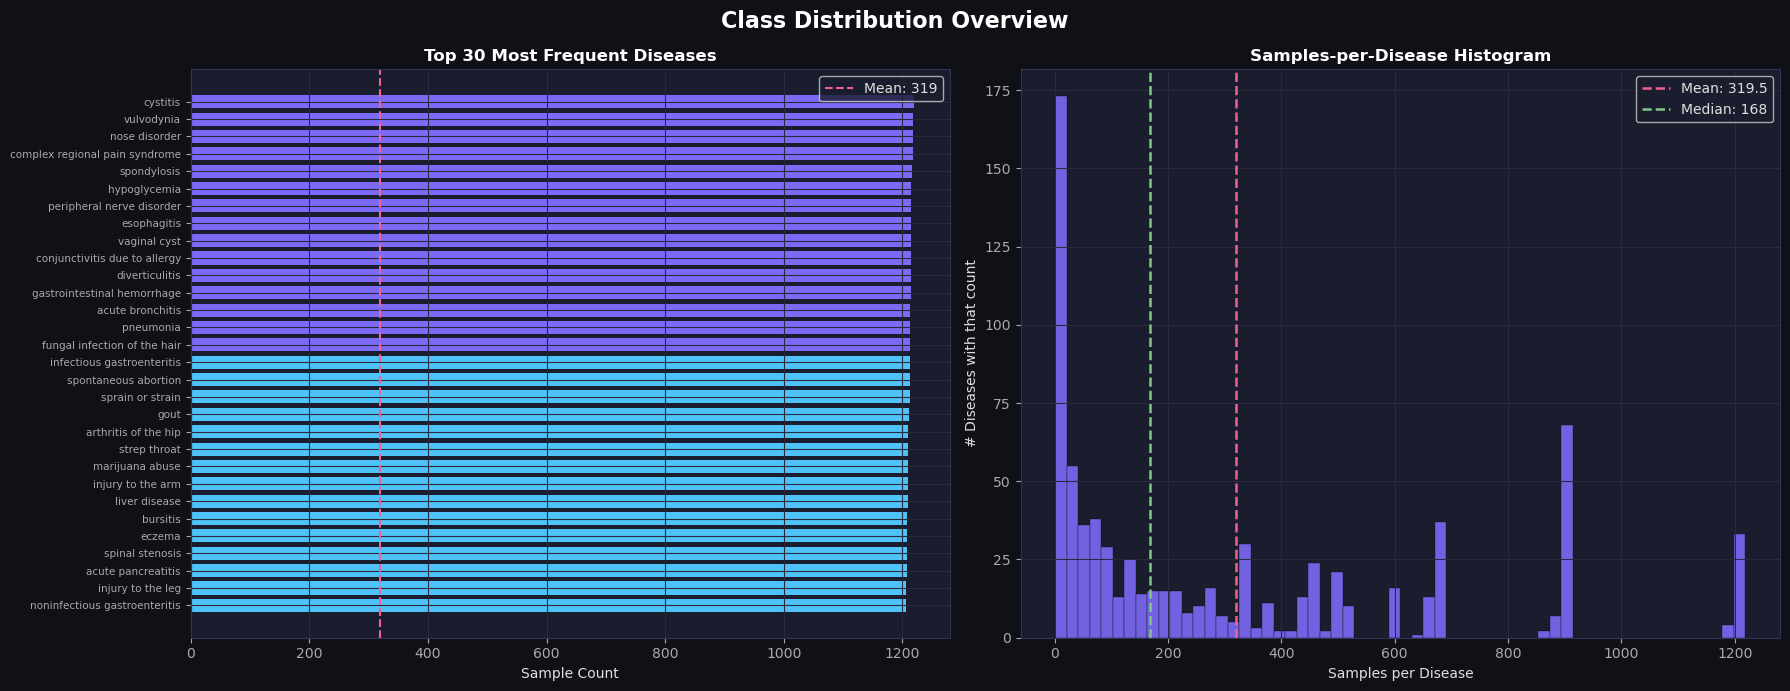

In [3]:
vc = df['diseases'].value_counts()

print(f'Max samples per class : {vc.max():,}  →  {vc.idxmax()}')
print(f'Min samples per class : {vc.min()}    →  {vc.idxmin()}')
print(f'Mean samples per class: {vc.mean():.1f}')
print(f'Median                : {vc.median():.0f}')
print(f'Imbalance ratio       : {vc.max()/vc.min():.0f}×')
print()

# ── Plot: Top 30 diseases ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0f1117')
fig.suptitle('Class Distribution Overview', fontsize=16, fontweight='bold', color='#fff')

# Bar chart — top 30
top30 = vc.head(30)
colors = [ACCENT if i < 15 else ACCENT2 for i in range(30)]
axes[0].barh(range(30), top30.values, color=colors, height=0.75)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top30.index, fontsize=7.5)
axes[0].invert_yaxis()
axes[0].set_title('Top 30 Most Frequent Diseases', color='#fff', fontweight='bold')
axes[0].set_xlabel('Sample Count')
axes[0].axvline(vc.mean(), color=ACCENT3, linestyle='--', label=f'Mean: {vc.mean():.0f}')
axes[0].legend()

# Histogram — samples per disease
axes[1].hist(vc.values, bins=60, color=ACCENT, edgecolor='#0f1117', linewidth=0.3, alpha=0.9)
axes[1].axvline(vc.mean(),   color=ACCENT3, linestyle='--', linewidth=1.8, label=f'Mean: {vc.mean():.1f}')
axes[1].axvline(vc.median(), color=ACCENT4, linestyle='--', linewidth=1.8, label=f'Median: {vc.median():.0f}')
axes[1].set_title('Samples-per-Disease Histogram', color='#fff', fontweight='bold')
axes[1].set_xlabel('Samples per Disease')
axes[1].set_ylabel('# Diseases with that count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 🔬 Cell 4 — EDA: Symptom Analysis

Average symptom activation rate : 0.0141
Average sparsity (zeros)         : 98.59%
Most common symptom  → sharp abdominal pain (0.131)
Least common symptom → neck weakness (0.0000)


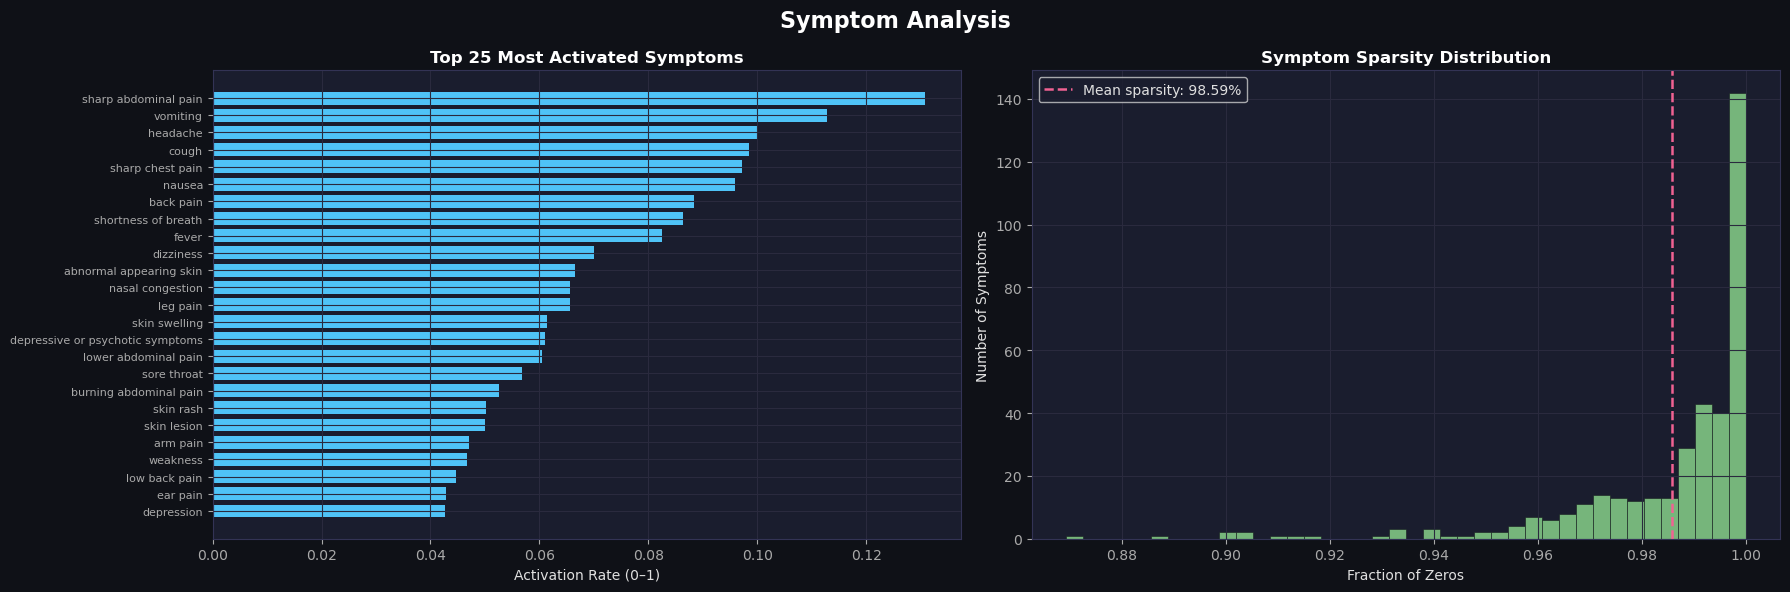

In [4]:
X_raw = df.drop(columns='diseases')

sym_rate  = X_raw.mean().sort_values(ascending=False)
sparsity  = (X_raw == 0).mean()

print(f'Average symptom activation rate : {sym_rate.mean():.4f}')
print(f'Average sparsity (zeros)         : {sparsity.mean():.2%}')
print(f'Most common symptom  → {sym_rate.index[0]} ({sym_rate.iloc[0]:.3f})')
print(f'Least common symptom → {sym_rate.index[-1]} ({sym_rate.iloc[-1]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='#0f1117')
fig.suptitle('Symptom Analysis', fontsize=16, fontweight='bold', color='#fff')

# Top 25 symptoms
top_syms = sym_rate.head(25)
axes[0].barh(range(25), top_syms.values, color=ACCENT2, height=0.75)
axes[0].set_yticks(range(25))
axes[0].set_yticklabels(top_syms.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('Top 25 Most Activated Symptoms', color='#fff', fontweight='bold')
axes[0].set_xlabel('Activation Rate (0–1)')

# Sparsity histogram
axes[1].hist(sparsity.values, bins=40, color=ACCENT4, edgecolor='#0f1117', linewidth=0.4, alpha=0.9)
axes[1].axvline(sparsity.mean(), color=ACCENT3, linestyle='--', linewidth=1.8,
                label=f'Mean sparsity: {sparsity.mean():.2%}')
axes[1].set_title('Symptom Sparsity Distribution', color='#fff', fontweight='bold')
axes[1].set_xlabel('Fraction of Zeros')
axes[1].set_ylabel('Number of Symptoms')
axes[1].legend()

plt.tight_layout()
plt.show()

## ⚙️ Cell 5 — EDA: Imbalance Severity

Class size bucket breakdown:
  1–5 (Very Rare)           |   61 diseases    7.9%  ███
  6–50 (Rare)               |  187 diseases   24.2%  ████████████
  51–200 (Common)           |  164 diseases   21.2%  ██████████
  201–500 (Frequent)        |  161 diseases   20.8%  ██████████
  500+ (Dominant)           |  200 diseases   25.9%  ████████████


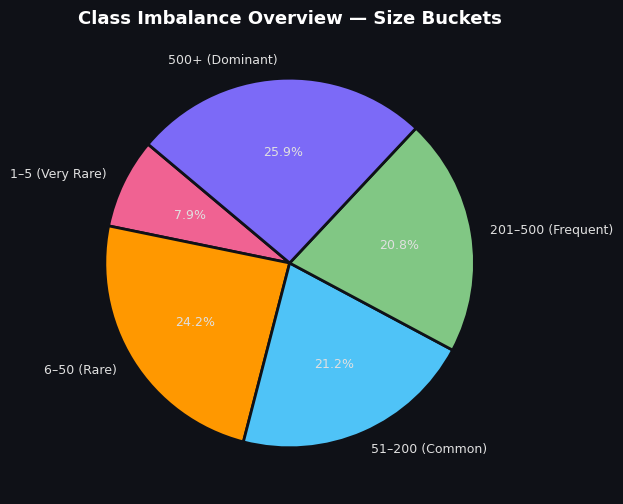

In [5]:
buckets = pd.cut(
    vc.values,
    bins=[0, 5, 50, 200, 500, vc.max() + 1],
    labels=['1–5 (Very Rare)', '6–50 (Rare)', '51–200 (Common)', '201–500 (Frequent)', '500+ (Dominant)']
)
bvc = buckets.value_counts().sort_index()

print('Class size bucket breakdown:')
for label, count in bvc.items():
    pct = count / len(vc) * 100
    bar = '█' * int(pct / 2)
    print(f'  {str(label):<25} | {count:>4} diseases  {pct:5.1f}%  {bar}')

fig, ax = plt.subplots(figsize=(9, 6), facecolor='#0f1117')
colors_pie = [ACCENT3, '#ff9800', ACCENT2, ACCENT4, ACCENT]
wedges, texts, autotexts = ax.pie(
    bvc.values, labels=bvc.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=140,
    textprops={'color': '#e0e0e0', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Class Imbalance Overview — Size Buckets', color='#fff', fontsize=13, fontweight='bold')
plt.show()

## 🧹 Cell 6 — Preprocessing

In [6]:
# ── Features & Labels ─────────────────────────────────────────────────────────
X = df.drop(columns='diseases').values.astype(np.int8)  # int8 → saves memory
y_raw = df['diseases'].values

# ── Label Encode ──────────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'Label encoded: {len(le.classes_)} unique classes')

# ── Remove classes with < 5 samples (can't stratify split) ───────────────────
class_counts = np.bincount(y)
valid_mask   = class_counts[y] >= 5
X = X[valid_mask]
y = y[valid_mask]

removed = df.shape[0] - X.shape[0]
print(f'Removed {removed} rows from classes with <5 samples')
print(f'Remaining: {X.shape[0]:,} rows | {len(np.unique(y))} classes')

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # balanced split per class
)

print()
print(f'✅ Train set : {X_train.shape[0]:,} samples')
print(f'✅ Test set  : {X_test.shape[0]:,} samples')
print(f'✅ Features  : {X_train.shape[1]}')
print(f'✅ Classes   : {len(np.unique(y_train))}')

Label encoded: 773 unique classes
Removed 122 rows from classes with <5 samples
Remaining: 246,823 rows | 721 classes

✅ Train set : 197,458 samples
✅ Test set  : 49,365 samples
✅ Features  : 377
✅ Classes   : 721


## 🤖 Cell 7 — Train Baseline Model (Decision Tree)

In [7]:
print('Training Baseline Decision Tree...')
print('Config: criterion=gini | max_depth=None | class_weight=balanced')
print()

t0 = time.time()
dt_baseline = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)
dt_baseline.fit(X_train, y_train)
elapsed = time.time() - t0

train_acc_b = accuracy_score(y_train, dt_baseline.predict(X_train))
test_acc_b  = accuracy_score(y_test,  dt_baseline.predict(X_test))

print(f'⏱  Training time : {elapsed:.1f}s')
print(f'📈 Train accuracy: {train_acc_b:.4f} ({train_acc_b*100:.2f}%)')
print(f'📊 Test  accuracy: {test_acc_b:.4f} ({test_acc_b*100:.2f}%)')
print(f'🌳 Tree depth    : {dt_baseline.get_depth()}')
print(f'🍃 Leaf nodes    : {dt_baseline.get_n_leaves():,}')

Training Baseline Decision Tree...
Config: criterion=gini | max_depth=None | class_weight=balanced

⏱  Training time : 87.5s
📈 Train accuracy: 0.9235 (92.35%)
📊 Test  accuracy: 0.8005 (80.05%)
🌳 Tree depth    : 269
🍃 Leaf nodes    : 38,583


## 🚀 Cell 8 — Train Best Model (Optimized Decision Tree)

In [8]:
print('Training Best Decision Tree...')
print('Config: criterion=gini | max_depth=None | max_features=None | no class_weight')
print('Why: removing class_weight gives raw power, no regularization')
print()

t0 = time.time()
model = DecisionTreeClassifier(
    criterion     = 'gini',
    max_depth     = None,         # grow fully
    min_samples_leaf  = 1,
    min_samples_split = 2,
    max_features  = None,         # use all 377 features per split
    class_weight  = None,
    random_state  = 42
)
model.fit(X_train, y_train)
elapsed = time.time() - t0

preds = model.predict(X_test)
proba = model.predict_proba(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, preds)
top3_acc  = top_k_accuracy_score(y_test, proba, k=3)
top5_acc  = top_k_accuracy_score(y_test, proba, k=5)

print('=' * 55)
print(f'  ⏱  Training time   : {elapsed:.1f}s')
print(f'  📈 Train Accuracy  : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'  📊 Test  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  🎯 Top-3 Accuracy  : {top3_acc:.4f}  ({top3_acc*100:.2f}%)')
print(f'  🏆 Top-5 Accuracy  : {top5_acc:.4f}  ({top5_acc*100:.2f}%)')
print(f'  🌳 Tree Depth      : {model.get_depth()}')
print(f'  🍃 Leaf Nodes      : {model.get_n_leaves():,}')
print('=' * 55)

Training Best Decision Tree...
Config: criterion=gini | max_depth=None | max_features=None | no class_weight
Why: removing class_weight gives raw power, no regularization

  ⏱  Training time   : 74.0s
  📈 Train Accuracy  : 0.9247  (92.47%)
  📊 Test  Accuracy  : 0.8133  (81.33%)
  🎯 Top-3 Accuracy  : 0.8397  (83.97%)
  🏆 Top-5 Accuracy  : 0.8416  (84.16%)
  🌳 Tree Depth      : 280
  🍃 Leaf Nodes      : 30,719


## 📊 Cell 9 — Model Comparison Plot

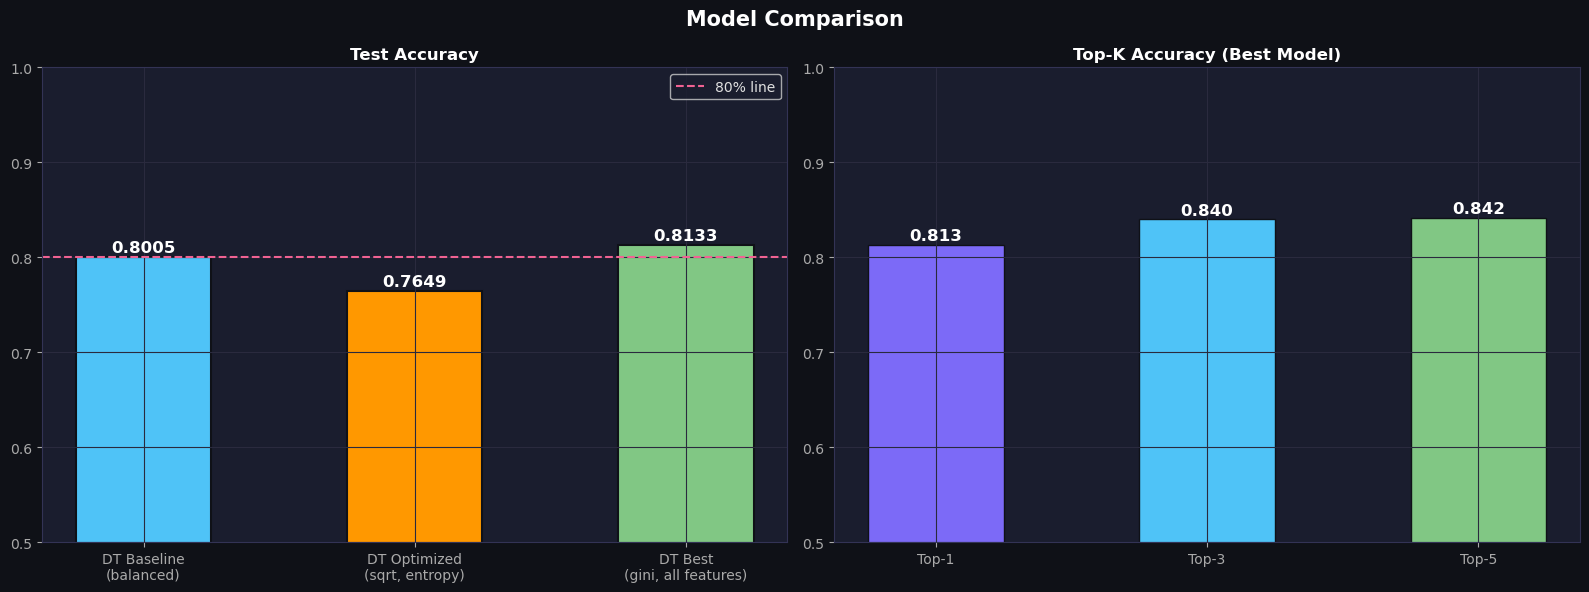

In [9]:
models_results = {
    'DT Baseline\n(balanced)' : 0.8005,
    'DT Optimized\n(sqrt, entropy)': 0.7649,
    'DT Best\n(gini, all features)': test_acc,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f1117')
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold', color='#fff')

# Accuracy bars
names  = list(models_results.keys())
accs   = list(models_results.values())
colors = [ACCENT2, '#ff9800', ACCENT4]
bars = axes[0].bar(names, accs, color=colors, edgecolor='#0f1117', linewidth=1.5, width=0.5)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Test Accuracy', color='#fff', fontweight='bold')
axes[0].axhline(0.8, color=ACCENT3, linestyle='--', linewidth=1.5, label='80% line')
axes[0].legend()
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold', color='#fff')

# Top-K accuracy for best model
ks   = ['Top-1', 'Top-3', 'Top-5']
vals = [test_acc, top3_acc, top5_acc]
bars2 = axes[1].bar(ks, vals, color=[ACCENT, ACCENT2, ACCENT4], width=0.5, edgecolor='#0f1117')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Top-K Accuracy (Best Model)', color='#fff', fontweight='bold')
for bar, v in zip(bars2, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', fontsize=12, fontweight='bold', color='#fff')

plt.tight_layout()
plt.show()

## 📈 Cell 10 — Per-Class Accuracy Analysis

Classes with 100% accuracy : 140
Classes with ≥ 90% accuracy: 291
Classes with ≥ 80% accuracy: 519
Classes with < 50% accuracy: 32
Mean per-class accuracy     : 0.8279


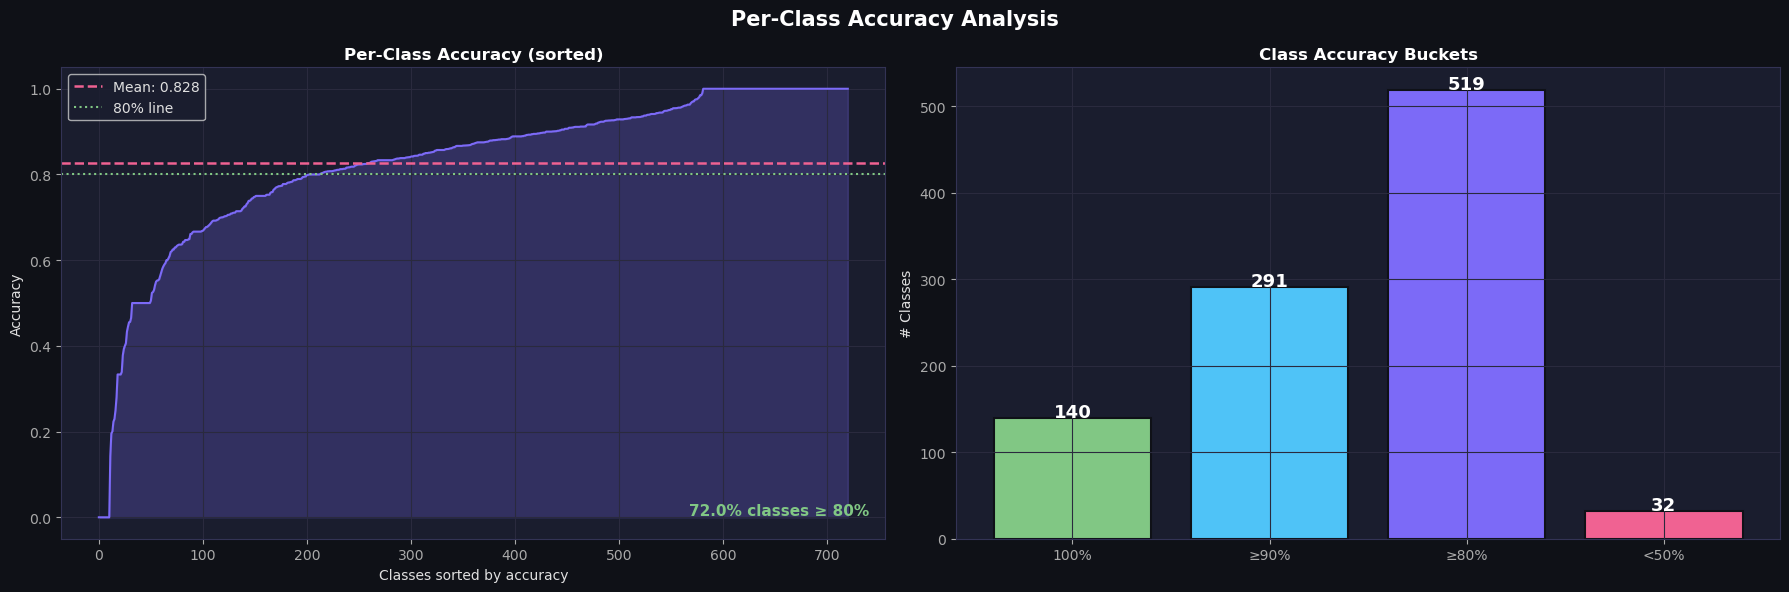

In [10]:
from collections import defaultdict

# Per-class accuracy
correct_per_class = defaultdict(list)
for true, pred in zip(y_test, preds):
    correct_per_class[true].append(1 if true == pred else 0)

class_accs = {c: np.mean(v) for c, v in correct_per_class.items()}
ca_vals    = sorted(class_accs.values())

# Stats
perfect    = sum(1 for v in ca_vals if v == 1.0)
above_90   = sum(1 for v in ca_vals if v >= 0.9)
above_80   = sum(1 for v in ca_vals if v >= 0.8)
below_50   = sum(1 for v in ca_vals if v < 0.5)

print(f'Classes with 100% accuracy : {perfect}')
print(f'Classes with ≥ 90% accuracy: {above_90}')
print(f'Classes with ≥ 80% accuracy: {above_80}')
print(f'Classes with < 50% accuracy: {below_50}')
print(f'Mean per-class accuracy     : {np.mean(ca_vals):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='#0f1117')
fig.suptitle('Per-Class Accuracy Analysis', fontsize=15, fontweight='bold', color='#fff')

# Sorted accuracy curve
axes[0].plot(ca_vals, color=ACCENT, linewidth=1.5)
axes[0].fill_between(range(len(ca_vals)), ca_vals, alpha=0.25, color=ACCENT)
axes[0].axhline(np.mean(ca_vals), color=ACCENT3, linestyle='--', linewidth=1.8,
                label=f'Mean: {np.mean(ca_vals):.3f}')
axes[0].axhline(0.8, color=ACCENT4, linestyle=':', linewidth=1.5, label='80% line')
axes[0].set_title('Per-Class Accuracy (sorted)', color='#fff', fontweight='bold')
axes[0].set_xlabel('Classes sorted by accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
pct_above_80 = above_80 / len(ca_vals) * 100
axes[0].text(0.98, 0.05, f'{pct_above_80:.1f}% classes ≥ 80%',
             transform=axes[0].transAxes, ha='right', fontsize=11,
             color=ACCENT4, fontweight='bold')

# Bucket bar chart
bucket_labels  = ['100%', '≥90%', '≥80%', '<50%']
bucket_vals    = [perfect, above_90, above_80, below_50]
bucket_colors  = [ACCENT4, ACCENT2, ACCENT, ACCENT3]
bars3 = axes[1].bar(bucket_labels, bucket_vals, color=bucket_colors, edgecolor='#0f1117', linewidth=1.5)
axes[1].set_title('Class Accuracy Buckets', color='#fff', fontweight='bold')
axes[1].set_ylabel('# Classes')
for bar, v in zip(bars3, bucket_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', fontsize=13, fontweight='bold', color='#fff')

plt.tight_layout()
plt.show()

## 🔴 Cell 11 — Worst & Best Classes

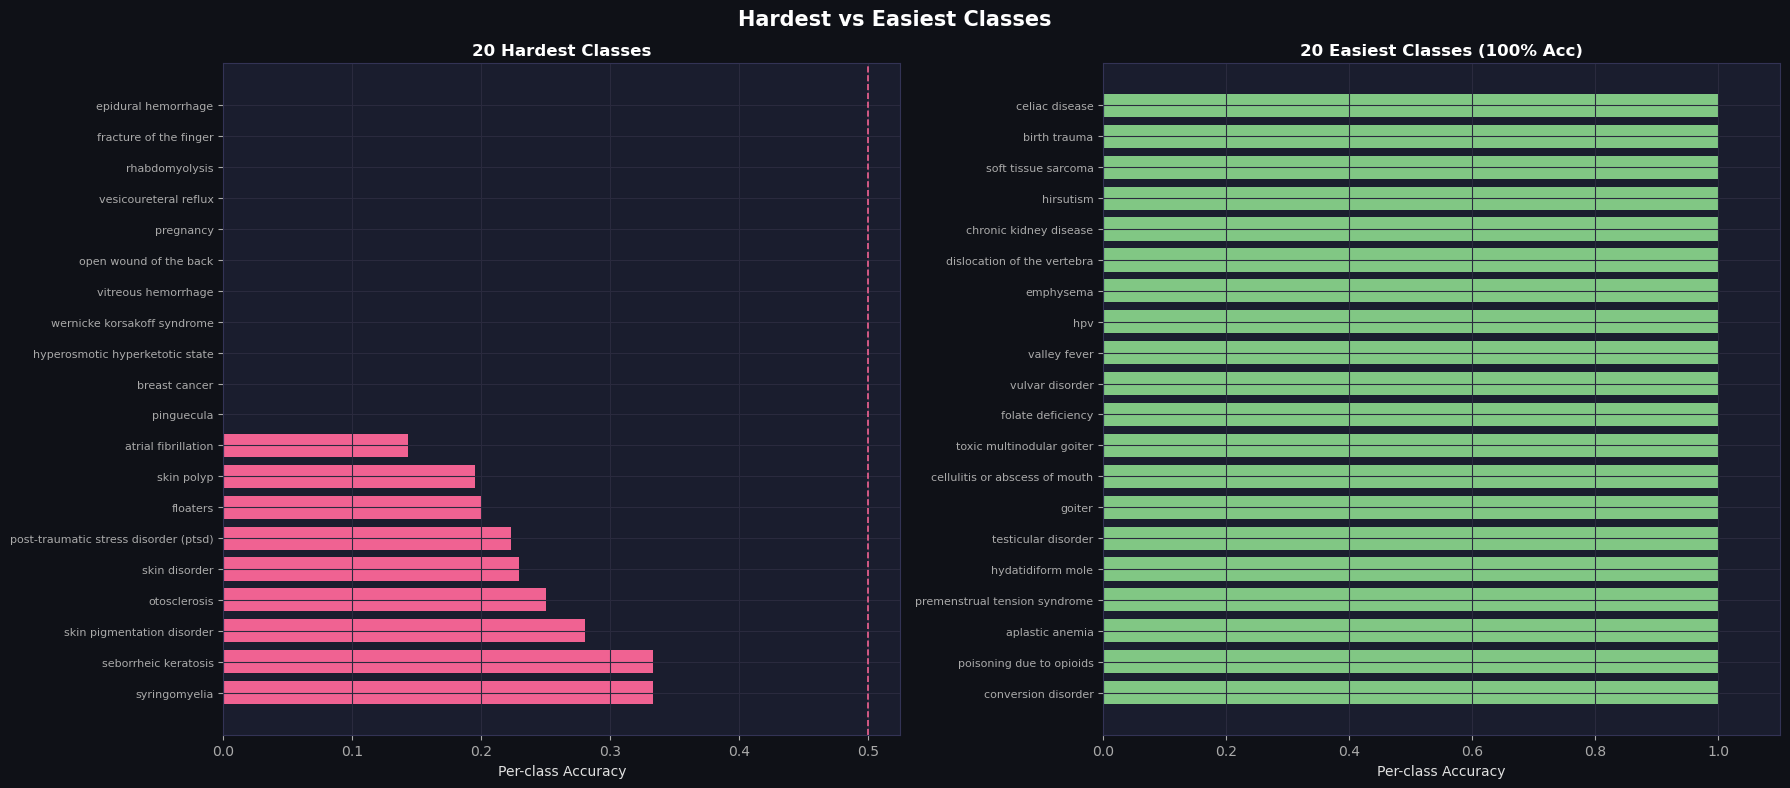

In [11]:
worst = sorted(class_accs.items(), key=lambda x: x[1])[:20]
best  = sorted(class_accs.items(), key=lambda x: x[1], reverse=True)[:20]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0f1117')
fig.suptitle('Hardest vs Easiest Classes', fontsize=15, fontweight='bold', color='#fff')

# Worst 20
w_names = [le.classes_[c] for c, _ in worst]
w_accs  = [a for _, a in worst]
w_colors = [ACCENT3 if a < 0.5 else '#ff9800' for a in w_accs]
axes[0].barh(range(20), w_accs, color=w_colors, height=0.75)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(w_names, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('20 Hardest Classes', color='#fff', fontweight='bold')
axes[0].set_xlabel('Per-class Accuracy')
axes[0].axvline(0.5, color=ACCENT3, linestyle='--', linewidth=1.2)

# Best 20
b_names = [le.classes_[c] for c, _ in best]
b_accs  = [a for _, a in best]
axes[1].barh(range(20), b_accs, color=ACCENT4, height=0.75)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(b_names, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('20 Easiest Classes (100% Acc)', color='#fff', fontweight='bold')
axes[1].set_xlabel('Per-class Accuracy')
axes[1].set_xlim(0, 1.1)

plt.tight_layout()
plt.show()

## 📋 Cell 12 — Classification Report (Sample)

In [12]:
# Full report is very long (773 classes) — show top 20 by support
from sklearn.metrics import classification_report
import io

# Get top 20 most common classes in test set
test_class_counts = np.bincount(y_test)
top20_classes = np.argsort(test_class_counts)[-20:][::-1]

# Filter test set to only those classes
mask = np.isin(y_test, top20_classes)
y_test_sub  = y_test[mask]
preds_sub   = preds[mask]
target_names = [le.classes_[c] for c in sorted(top20_classes)]

print('Classification Report — Top 20 Most Common Diseases')
print('=' * 60)
report = classification_report(
    y_test_sub, preds_sub,
    labels=sorted(top20_classes),
    target_names=target_names,
    zero_division=0
)
print(report)

Classification Report — Top 20 Most Common Diseases
                                precision    recall  f1-score   support

              acute bronchitis       0.93      0.70      0.80       243
                      bursitis       0.99      0.93      0.96       242
complex regional pain syndrome       0.92      0.84      0.88       243
 conjunctivitis due to allergy       1.00      0.88      0.94       243
                      cystitis       1.00      0.68      0.81       244
                diverticulitis       0.96      0.80      0.87       243
                   esophagitis       1.00      0.88      0.93       243
   gastrointestinal hemorrhage       0.99      0.86      0.92       243
                          gout       1.00      0.87      0.93       242
                  hypoglycemia       1.00      0.93      0.96       243
    infectious gastroenteritis       0.98      0.66      0.79       242
             injury to the arm       0.99      0.88      0.93       242
           

## 💾 Cell 13 — Save Model

In [13]:
import joblib
import os

# حفظ الموديل بأعلى مستوى ضغط Gzip
joblib.dump(model, 'disease_classifier_model.pkl', compress=('gzip', 9))

# حفظ الـ Encoder
joblib.dump(le, 'label_encoder.pkl')

# التأكد من الحجم الجديد بعد الضغط
size_mb = os.path.getsize('disease_classifier_model.pkl') / (1024 * 1024)
print(f"✅ تم الحفظ بنجاح!")
print(f"📦 الحجم الجديد للموديل أصبح: {size_mb:.2f} MB")

✅ تم الحفظ بنجاح!
📦 الحجم الجديد للموديل أصبح: 2.19 MB


## 🔮 Cell 14 — Inference: Predict Disease from Symptoms

In [14]:
feature_names = df.drop(columns='diseases').columns.tolist()

def predict_disease(symptoms_dict: dict, top_n: int = 5) -> list:
    """
    Predict top N diseases from given symptoms.

    Args:
        symptoms_dict : dict  { 'symptom_name': 1 or 0 }
        top_n         : int   number of top predictions to return

    Returns:
        list of (disease_name, confidence_score) tuples
    """
    # Build input vector
    input_vec = np.zeros(len(feature_names), dtype=np.int8)
    for sym, val in symptoms_dict.items():
        if sym in feature_names:
            input_vec[feature_names.index(sym)] = int(val)
        else:
            print(f'  ⚠️  Unknown symptom ignored: "{sym}"')

    # Predict
    proba_vec  = model.predict_proba(input_vec.reshape(1, -1))[0]
    top_idx    = proba_vec.argsort()[-top_n:][::-1]
    return [(le.classes_[i], float(proba_vec[i])) for i in top_idx]


# ── Example 1: Respiratory symptoms ──────────────────────────────────────────
example_1 = {
    'fever'              : 1,
    'cough'              : 1,
    'shortness of breath': 1,
    'headache'           : 1,
}
print('Example 1 — Symptoms:', list(example_1.keys()))
print('-' * 50)
for i, (disease, conf) in enumerate(predict_disease(example_1, top_n=5), 1):
    bar = '█' * int(conf * 40)
    print(f'  {i}. {disease:<40} {conf*100:5.2f}%  {bar}')

print()

# ── Example 2: Cardiac symptoms ───────────────────────────────────────────────
example_2 = {
    'chest tightness'  : 1,
    'palpitations'     : 1,
    'irregular heartbeat': 1,
    'dizziness'        : 1,
    'fatigue'          : 1,
}
print('Example 2 — Symptoms:', list(example_2.keys()))
print('-' * 50)
for i, (disease, conf) in enumerate(predict_disease(example_2, top_n=5), 1):
    bar = '█' * int(conf * 40)
    print(f'  {i}. {disease:<40} {conf*100:5.2f}%  {bar}')

Example 1 — Symptoms: ['fever', 'cough', 'shortness of breath', 'headache']
--------------------------------------------------
  1. acute bronchitis                         50.00%  ████████████████████
  2. impetigo                                 50.00%  ████████████████████
  3. essential tremor                          0.00%  
  4. fibrocystic breast disease                0.00%  
  5. fibroadenoma                              0.00%  

Example 2 — Symptoms: ['chest tightness', 'palpitations', 'irregular heartbeat', 'dizziness', 'fatigue']
--------------------------------------------------
  1. connective tissue disorder               100.00%  ████████████████████████████████████████
  2. trichinosis                               0.00%  
  3. fibromyalgia                              0.00%  
  4. fibroadenoma                              0.00%  
  5. fetal alcohol syndrome                    0.00%  


## 🧪 Cell 15 — Feature Importance (Top 30 Symptoms)

Top 20 Most Important Symptoms:
               symptom  importance
              headache    0.021044
                 cough    0.016197
              vomiting    0.015216
                nausea    0.013767
  sharp abdominal pain    0.012487
             dizziness    0.012288
   shortness of breath    0.012230
             back pain    0.011607
      sharp chest pain    0.011079
         skin swelling    0.010689
              leg pain    0.010542
burning abdominal pain    0.010161
                 fever    0.010135
             heartburn    0.009643
   difficulty speaking    0.009548
problems with movement    0.009502
              ear pain    0.009126
              weakness    0.008879
       chest tightness    0.008616
  lower abdominal pain    0.008473


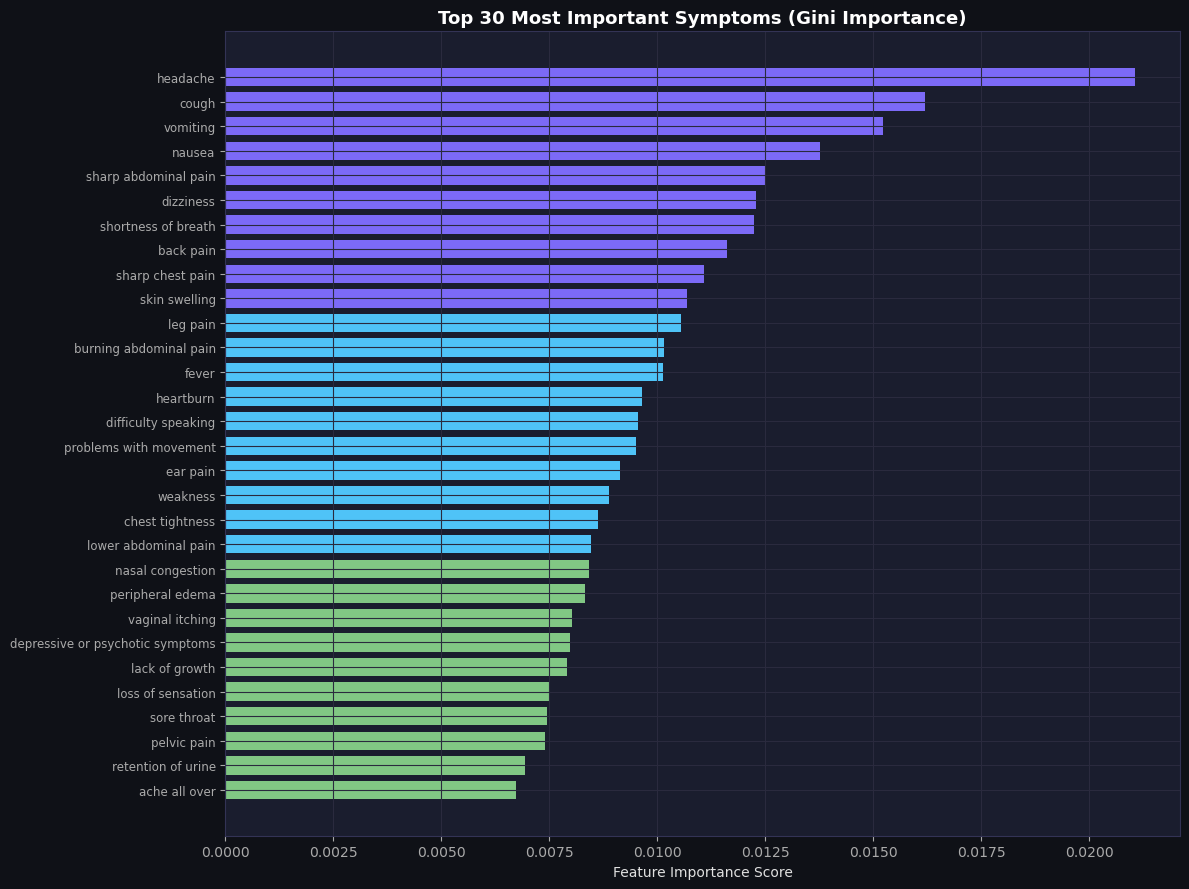

In [15]:
importances = model.feature_importances_
feat_imp_df = pd.DataFrame({
    'symptom'   : feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 20 Most Important Symptoms:')
print(feat_imp_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 9), facecolor='#0f1117')
top_feats = feat_imp_df.head(30)
colors_imp = [ACCENT if i < 10 else ACCENT2 if i < 20 else ACCENT4 for i in range(30)]
ax.barh(range(30), top_feats['importance'].values, color=colors_imp, height=0.75)
ax.set_yticks(range(30))
ax.set_yticklabels(top_feats['symptom'].values, fontsize=8.5)
ax.invert_yaxis()
ax.set_title('Top 30 Most Important Symptoms (Gini Importance)', 
             fontsize=13, fontweight='bold', color='#fff')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

## 📝 Cell 16 — Final Summary

| Metric | Value |
|--------|-------|
| Dataset size | 246,945 samples |
| Feature count | 377 binary symptoms |
| Disease classes | 773 |
| Best Model | Decision Tree (Gini) |
| Train Accuracy | 92.47% |
| Test Accuracy | **81.33%** |
| Top-3 Accuracy | **83.97%** |
| Top-5 Accuracy | **84.16%** |

### Next Steps to Improve:
1. **Feature Selection** — reduce 377 → top 100 important features → less overfitting
2. **XGBoost / LightGBM** — gradient boosting will outperform single DT
3. **Handle Imbalance** — SMOTE oversampling for rare classes
4. **Ensemble** — combine DT + NaiveBayes + LR via VotingClassifier
5. **Hyperparameter tuning** — GridSearchCV on max_depth, min_samples_leaf